#Assignment : SQL

Question 1 : Explain the fundamental differences between DDL, DML, and DQL
commands in SQL. Provide one example for each type of command.




answer:
DDL is basically data defination language used to define or change the structure of database objects like create, modify or delete databases.


DDL COMMANDS
- CREATE : (Used to create a new table.)
CREATE TABLE Students (
    StudentID INT PRIMARY KEY,
    StudentName VARCHAR(100)
);
- ALTER :
(Used to modify an existing table.)
ALTER TABLE Students
ADD Email VARCHAR(100);
- DROP :(Used to permanently delete a table.)
 DROP TABLE Students;
- TRUNCATE :(Used to remove all records from a table.) TRUNCATE TABLE Students;







DML is basically data manupulation language used to Insert, update, or delete data inside tables.

DML COMMANDS
- INSERT
: (Used to add data into a table. ) INSERT INTO Students
VALUES
(1, 'Rahul');
- UPDATE :
(Used to modify existing data.)
UPDATE Students
SET StudentName = 'Aman'
WHERE StudentID = 1;
- DELETE :(
Used to remove specific records.)
DELETE FROM Students
WHERE StudentID = 1;

DQL is basically data query language used to Retrieve or view data from the database.


DQL COMMANDS
- SELECT (DQL)

Used to retrieve data from a table.

SELECT * FROM Students;

Question 2 :What is the purpose of SQL constraints? Name and describe three common types
of constraints, providing a simple scenario where each would be useful.


answer: constraints are rules applied to table columns to
maintain accuracy, consistency, and reliability of data in a database.
They help prevent invalid or duplicate data from being stored.

- primary key  is used for uniqueness and not empty data in each row.
- not null ensure that column cant contain empty data.
- foreign key is used to establish relationship between two tables.

Question 3 : Explain the difference between LIMIT and OFFSET clauses in SQL. How would you use them together to retrieve the third page of results, assuming each page has 10 records?

answer: both LIMIT and OFFSET are used for pagination in SQL queries.

Clause	          Purpose
LIMIT	            Specifies number of records to return
OFFSET	          Specifies number of records to skip

###LIMIT

Example:
SELECT * FROM Products
LIMIT 10;

This returns only 10 rows.

###OFFSET

Example:
SELECT * FROM Products
LIMIT 10 OFFSET 5;

This skips first 5 rows and returns next 10 rows.

Question 4 : What is a Common Table Expression (CTE) in SQL, and what are its main benefits? Provide a simple SQL example demonstrating its usage.

answer:

A Common Table Expression (CTE) is a temporary result set defined using the WITH keyword. It exists only during execution of a query.

###Benefits of CTE:
- Improves readability of complex queries
- Simplifies query writing
- Helps break large queries into smaller parts
- Can be reused within the same query
- Supports recursive queries

- Syntax:

WITH CTE_Name AS (
    SELECT column_name
    FROM table_name
)
SELECT * FROM CTE_Name;

- Example:

WITH HighSalaryEmployees AS (
    SELECT EmployeeName, Salary
    FROM Employees
    WHERE Salary > 50000
)

SELECT * FROM HighSalaryEmployees;


Question 5 : Describe the concept of SQL Normalization and its primary goals. Briefly explain the first three normal forms (1NF, 2NF, 3NF).

answer:

Normalization is the process of organizing data in a database to reduce redundancy and improve data integrity.

###Goals of Normalization:
- Eliminate duplicate data
- Improve data consistency
- Reduce update anomalies
- Improve database efficiency

##First Normal Form (1NF)

Rules:
Each column must contain atomic values
No repeating groups
Example:

Incorrect:

Student	Subjects
Rahul	Math, Science

Correct:

Student	Subject
- Rahul	Math
- Rahul	Science

##Second Normal Form (2NF)
Rules:
Must already be in 1NF
No partial dependency
Explanation:

Non-key attributes must depend on the whole primary key.

##Third Normal Form (3NF)
Rules:
Must already be in 2NF
No transitive dependency
Explanation:

Non-key columns should not depend on other non-key columns

In [ ]:
### Question 6 : Create a database named ECommerceDB and perform the following tasks:
create database ECommerceDB;
use ECommerceDB;

create table Categories
(categoryID int primary key,
categoryNAME varchar(50) not null unique);

insert into Categories (CategoryID, CategoryName)
values
(1, 'Electronics'),
(2, 'Books'),
(3, 'Home Goods'),
(4, 'Apparel');

create table Products
( productID int primary key,
productName varchar(100) not null unique,
categoryID int , foreign key(categoryID) references Categories (categoryID),
price decimal(10,2) not null,
stockQuantity int);

insert into Products
values (101,"Laptop Pro", 1,1200.00,50),
(102, "SQLHandbook", 2 ,45.50,200),
(103 ,"Smart Speaker ",1 ,99.99 ,150),
(104 ,"Coffee Maker", 3, 75.00, 80),
(105, "Novel : The Great SQL", 2, 25.00, 120),
(106, "Wireless Earbuds", 1, 150.00, 100),
(107, "Blender X", 3, 120.00, 60),
(108, "T-Shirt Casual", 4, 20.00, 300);

create table Customers
(customerID int primary key,
customerName varchar(100) not null,
email varchar(100) unique,
joinDate date);

insert into Customers
values (1, "Alice Wonderland","alice@example.com ", "2023-01-10"),
(2, "Bob the Builder", "bob@example.com", "2022-11-25"),
(3, "Charlie Chaplin","charlie@example.com","2023-03-01"),
(4, "Diana Prince","diana@example.com","2021-04-26");

create table Orders
(orderID int primary key,
customerID int, foreign key (customerID) references Customers (customerID),
orderDate date not null,
totalAmount decimal(10,2));

insert into Orders
values
(1001,1, "2023-04-26", 1245.50),
(1002, 2, "2023-10-12", 99.99),
(1003, 1, "2023-07-01", 145.00),
(1004, 3, "2023-01-14", 150.00),
(1005, 2, "2023-09-24", 120.00),
(1006, 1, "2023-06-19", 20.00);

select * from Categories;
select * from Products;
select * from Customers;
select * from Orders;



##output 6
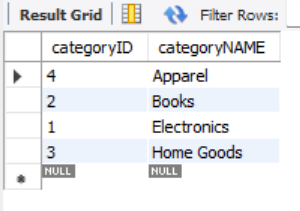

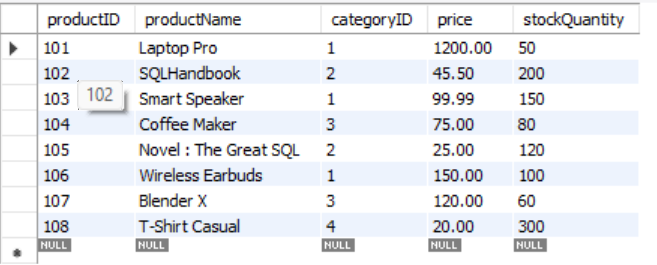

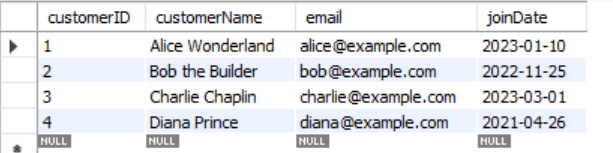

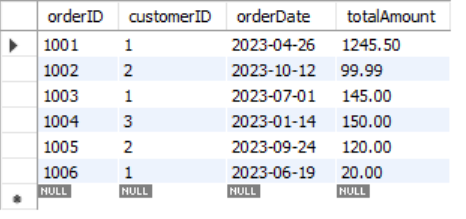

In [ ]:
# question 7 : Generate a report showing CustomerName, Email, and the TotalNumberofOrders for each customer. Include customers who have not placed any orders, in which case their TotalNumberofOrders should be 0. Order the results by CustomerName.

SELECT
    p.ProductName,
    p.Price,
    p.StockQuantity,
    c.CategoryName
FROM Products p
INNER JOIN Categories c
ON p.CategoryID = c.CategoryID
ORDER BY p.ProductName ASC, c.CategoryName ASC;


output 7:


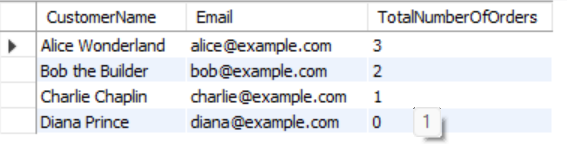

In [ ]:
# question 8:Retrieve Product Information with Category: Write a SQL query to display the ProductName, Price, StockQuantity, and CategoryName for all products. Order the results by CategoryName and then ProductName al

SELECT
    p.ProductName,
    p.Price,
    p.StockQuantity,
    c.CategoryName
FROM Products p
JOIN Categories c
ON p.CategoryID = c.CategoryID
ORDER BY c.CategoryName, p.ProductName;

output 8



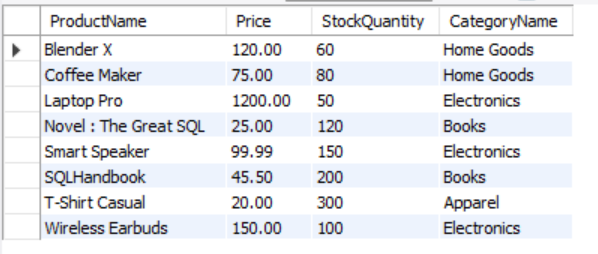

In [ ]:
# question 9: Write a SQL query that uses a Common Table Expression (CTE) and a Window Function (specifically ROW_NUMBER() or RANK()) to display the CategoryName, ProductName, and Price for the top 2 most expensive products in each CategoryName.

WITH RankedProducts AS (
    SELECT
        c.CategoryName,
        p.ProductName,
        p.Price,
        ROW_NUMBER() OVER (
            PARTITION BY c.CategoryName
            ORDER BY p.Price DESC
        ) AS RankNumber
    FROM Products p
    JOIN Categories c
    ON p.CategoryID = c.CategoryID
)

SELECT
    CategoryName,
    ProductName,
    Price
FROM RankedProducts
WHERE RankNumber <= 2;

output 9


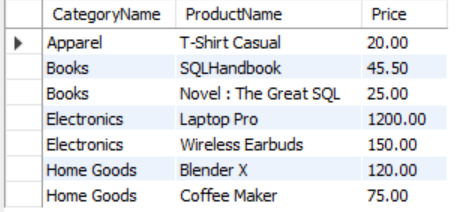

In [ ]:
# Question 10 : You are hired as a data analyst by Sakila Video Rentals, a global movie rental company. The management team is looking to improve decision-making by analyzing existing customer, rental, and inventory data. Using the Sakila database, answer the following business questions to support key strategic initiatives.

### Tasks & Questions:
# 1. Identify the top 5 customers based on the total amount they’ve spent. Include customer name, email, and total amount spent.
USE sakila;
SELECT
    CONCAT(c.first_name, ' ', c.last_name) AS CustomerName,
    c.email,
    SUM(p.amount) AS TotalAmountSpent
FROM customer c
JOIN payment p
ON c.customer_id = p.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name, c.email
ORDER BY TotalAmountSpent DESC
LIMIT 5;



output10 :
1)

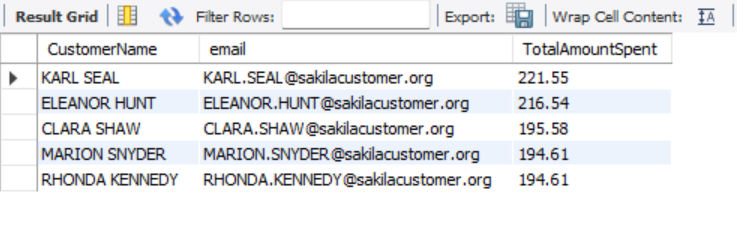

In [ ]:
# 2. Which 3 movie categories have the highest rental counts? Display the category name and number of times movies from that category were rented.
SELECT
    cat.name AS CategoryName,
    COUNT(r.rental_id) AS RentalCount
FROM category cat
JOIN film_category fc
ON cat.category_id = fc.category_id
JOIN inventory i
ON fc.film_id = i.film_id
JOIN rental r
ON i.inventory_id = r.inventory_id
GROUP BY cat.name
ORDER BY RentalCount DESC
LIMIT 3;

output10 : 2)



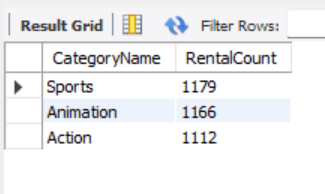

In [ ]:
# 3. Calculate how many films are available at each store and how many of those have never been rented.
SELECT
    s.store_id,
    COUNT(i.inventory_id) AS TotalFilms,
    COUNT(CASE WHEN r.rental_id IS NULL THEN 1 END) AS NeverRented
FROM store s
JOIN inventory i
ON s.store_id = i.store_id
LEFT JOIN rental r
ON i.inventory_id = r.inventory_id
GROUP BY s.store_id;

output10 : 3)


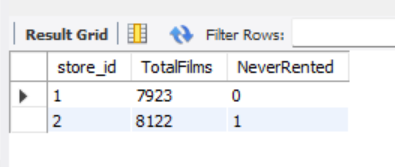

In [ ]:
# 4. Show the total revenue per month for the year 2023 to analyze business seasonality.
SELECT
    MONTH(payment_date) AS MonthNumber,
    MONTHNAME(payment_date) AS MonthName,
    SUM(amount) AS TotalRevenue
FROM payment
GROUP BY MONTH(payment_date), MONTHNAME(payment_date)
ORDER BY MonthNumber;

output10 : 4)



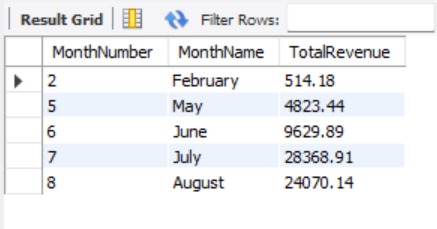

In [ ]:
# 5. Identify customers who have rented more than 10 times in the last 6 months.
SELECT
    c.customer_id,
    CONCAT(c.first_name, ' ', c.last_name) AS CustomerName,
    COUNT(r.rental_id) AS TotalRentals
FROM customer c
JOIN rental r
ON c.customer_id = r.customer_id
WHERE r.rental_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
GROUP BY c.customer_id, CustomerName
HAVING COUNT(r.rental_id) > 10;

In [ ]:
output10 : 5)
(output was long so copied it here)
customer_id, CustomerName, TotalRentals
'148', 'ELEANOR HUNT', '46'
'526', 'KARL SEAL', '45'
'144', 'CLARA SHAW', '42'
'236', 'MARCIA DEAN', '42'
'75', 'TAMMY SANDERS', '41'
'197', 'SUE PETERS', '40'
'469', 'WESLEY BULL', '40'
'137', 'RHONDA KENNEDY', '39'
'178', 'MARION SNYDER', '39'
'468', 'TIM CARY', '39'
'5', 'ELIZABETH BROWN', '38'
'295', 'DAISY BATES', '38'
'410', 'CURTIS IRBY', '38'
'459', 'TOMMY COLLAZO', '38'
'176', 'JUNE CARROLL', '37'
'198', 'ELSIE KELLEY', '37'
'257', 'MARSHA DOUGLAS', '37'
'366', 'BRANDON HUEY', '37'
'29', 'ANGELA HERNANDEZ', '36'
'267', 'MARGIE WADE', '36'
'348', 'ROGER QUINTANILLA', '36'
'354', 'JUSTIN NGO', '36'
'380', 'RUSSELL BRINSON', '36'
'439', 'ALEXANDER FENNELL', '36'
'21', 'MICHELLE CLARK', '35'
'50', 'DIANE COLLINS', '35'
'91', 'LOIS BUTLER', '35'
'196', 'ALMA AUSTIN', '35'
'204', 'ROSEMARY SCHMIDT', '35'
'273', 'PRISCILLA LOWE', '35'
'274', 'NAOMI JENNINGS', '35'
'368', 'HARRY ARCE', '35'
'371', 'BILLY POULIN', '35'
'373', 'LOUIS LEONE', '35'
'381', 'BOBBY BOUDREAU', '35'
'403', 'MIKE WAY', '35'
'506', 'LESLIE SEWARD', '35'
'26', 'JESSICA HALL', '34'
'30', 'MELISSA KING', '34'
'38', 'MARTHA GONZALEZ', '34'
'46', 'CATHERINE CAMPBELL', '34'
'66', 'JANICE WARD', '34'
'119', 'SHERRY MARSHALL', '34'
'129', 'CARRIE PORTER', '34'
'138', 'HAZEL WARREN', '34'
'147', 'JOANNE ROBERTSON', '34'
'168', 'REGINA BERRY', '34'
'181', 'ANA BRADLEY', '34'
'207', 'GERTRUDE CASTILLO', '34'
'211', 'STACEY MONTGOMERY', '34'
'239', 'MINNIE ROMERO', '34'
'241', 'HEIDI LARSON', '34'
'360', 'RALPH MADRIGAL', '34'
'372', 'STEVE MACKENZIE', '34'
'473', 'JORGE OLIVARES', '34'
'502', 'BRETT CORNWELL', '34'
'566', 'CASEY MENA', '34'
'576', 'MORRIS MCCARTER', '34'
'7', 'MARIA MILLER', '33'
'51', 'ALICE STEWART', '33'
'64', 'JUDITH COX', '33'
'84', 'SARA PERRY', '33'
'86', 'JACQUELINE LONG', '33'
'102', 'CRYSTAL FORD', '33'
'114', 'GRACE ELLIS', '33'
'172', 'BERNICE WILLIS', '33'
'230', 'JOY GEORGE', '33'
'237', 'TANYA GILBERT', '33'
'297', 'SHERRI RHODES', '33'
'314', 'GEORGE LINTON', '33'
'390', 'SHAWN HEATON', '33'
'438', 'BARRY LOVELACE', '33'
'451', 'JIM REA', '33'
'454', 'ALEX GRESHAM', '33'
'462', 'WARREN SHERROD', '33'
'522', 'ARNOLD HAVENS', '33'
'533', 'JESSIE MILAM', '33'
'1', 'MARY SMITH', '32'
'15', 'HELEN HARRIS', '32'
'28', 'CYNTHIA YOUNG', '32'
'35', 'VIRGINIA GREEN', '32'
'89', 'JULIA FLORES', '32'
'120', 'SYLVIA ORTIZ', '32'
'122', 'THELMA MURRAY', '32'
'125', 'ETHEL WEBB', '32'
'128', 'MARJORIE TUCKER', '32'
'141', 'DEBBIE REYES', '32'
'158', 'VERONICA STONE', '32'
'167', 'SALLY PIERCE', '32'
'209', 'TONYA CHAPMAN', '32'
'242', 'GLENDA FRAZIER', '32'
'244', 'VIOLA HANSON', '32'
'245', 'COURTNEY DAY', '32'
'254', 'MAXINE SILVA', '32'
'259', 'LENA JENSEN', '32'
'277', 'OLGA JIMENEZ', '32'
'306', 'CHARLES KOWALSKI', '32'
'329', 'FRANK WAGGONER', '32'
'342', 'HAROLD MARTINO', '32'
'346', 'ARTHUR SIMPKINS', '32'
'362', 'NICHOLAS BARFIELD', '32'
'405', 'LEONARD SCHOFIELD', '32'
'406', 'NATHAN RUNYON', '32'
'442', 'LEROY BUSTAMANTE', '32'
'452', 'TOM MILNER', '32'
'470', 'GORDON ALLARD', '32'
'503', 'ANGEL BARCLAY', '32'
'520', 'MITCHELL WESTMORELAND', '32'
'532', 'NEIL RENNER', '32'
'535', 'JAVIER ELROD', '32'
'550', 'GUY BROWNLEE', '32'
'569', 'DAVE GARDINER', '32'
'27', 'SHIRLEY ALLEN', '31'
'78', 'LORI WOOD', '31'
'103', 'GLADYS HAMILTON', '31'
'157', 'DARLENE ROSE', '31'
'186', 'HOLLY FOX', '31'
'210', 'ELLA OLIVER', '31'
'214', 'KRISTIN JOHNSTON', '31'
'251', 'VICKIE BREWER', '31'
'260', 'CHRISTY VARGAS', '31'
'279', 'DIANNE SHELTON', '31'
'293', 'MAE FLETCHER', '31'
'300', 'JOHN FARNSWORTH', '31'
'309', 'CHRISTOPHER GRECO', '31'
'323', 'MATTHEW MAHAN', '31'
'340', 'PATRICK NEWSOM', '31'
'361', 'LAWRENCE LAWTON', '31'
'393', 'PHILIP CAUSEY', '31'
'416', 'JEFFERY PINSON', '31'
'446', 'THEODORE CULP', '31'
'479', 'ZACHARY HITE', '31'
'494', 'RAMON CHOATE', '31'
'513', 'DUANE TUBBS', '31'
'20', 'SHARON ROBINSON', '30'
'23', 'SARAH LEWIS', '30'
'42', 'CAROLYN PEREZ', '30'
'53', 'HEATHER MORRIS', '30'
'56', 'GLORIA COOK', '30'
'71', 'KATHY JAMES', '30'
'72', 'THERESA WATSON', '30'
'80', 'MARILYN ROSS', '30'
'87', 'WANDA PATTERSON', '30'
'107', 'FLORENCE WOODS', '30'
'108', 'TRACY COLE', '30'
'112', 'ROSA REYNOLDS', '30'
'115', 'WENDY HARRISON', '30'
'131', 'MONICA HICKS', '30'
'135', 'JUANITA MASON', '30'
'154', 'MICHELE GRANT', '30'
'161', 'GERALDINE PERKINS', '30'
'256', 'MABEL HOLLAND', '30'
'269', 'CASSANDRA WALTERS', '30'
'275', 'CAROLE BARNETT', '30'
'289', 'VIOLET RODRIQUEZ', '30'
'296', 'RAMONA HALE', '30'
'299', 'JAMES GANNON', '30'
'307', 'JOSEPH JOY', '30'
'319', 'RONALD WEINER', '30'
'334', 'RAYMOND MCWHORTER', '30'
'336', 'JOSHUA MARK', '30'
'339', 'WALTER PERRYMAN', '30'
'347', 'RYAN SALISBURY', '30'
'356', 'GERALD FULTZ', '30'
'388', 'CRAIG MORRELL', '30'
'391', 'CLARENCE GAMEZ', '30'
'404', 'STANLEY SCROGGINS', '30'
'408', 'MANUEL MURRELL', '30'
'418', 'JEFF EAST', '30'
'424', 'KYLE SPURLOCK', '30'
'436', 'TROY QUIGLEY', '30'
'444', 'MARCUS HIDALGO', '30'
'472', 'GREG ROBINS', '30'
'484', 'ROBERTO VU', '30'
'499', 'MARC OUTLAW', '30'
'560', 'JORDAN ARCHULETA', '30'
'584', 'SALVADOR TEEL', '30'
'595', 'TERRENCE GUNDERSON', '30'
'25', 'DEBORAH WALKER', '29'
'32', 'AMY LOPEZ', '29'
'39', 'DEBRA NELSON', '29'
'52', 'JULIE SANCHEZ', '29'
'54', 'TERESA ROGERS', '29'
'113', 'CINDY FISHER', '29'
'146', 'JAMIE RICE', '29'
'163', 'CATHY SPENCER', '29'
'173', 'AUDREY RAY', '29'
'179', 'DANA HART', '29'
'253', 'TERRY CARLSON', '29'
'263', 'HILDA HOPKINS', '29'
'265', 'JENNIE TERRY', '29'
'268', 'NINA SOTO', '29'
'287', 'BECKY MILES', '29'
'302', 'MICHAEL SILVERMAN', '29'
'316', 'STEVEN CURLEY', '29'
'337', 'JERRY JORDON', '29'
'349', 'JOE GILLILAND', '29'
'363', 'ROY WHITING', '29'
'386', 'TODD TAN', '29'
'397', 'JIMMY SCHRADER', '29'
'447', 'CLIFFORD BOWENS', '29'
'448', 'MIGUEL BETANCOURT', '29'
'467', 'ALVIN DELOACH', '29'
'481', 'HERMAN DEVORE', '29'
'482', 'MAURICE CRAWLEY', '29'
'485', 'CLYDE TOBIAS', '29'
'529', 'ERIK GUILLEN', '29'
'538', 'TED BREAUX', '29'
'563', 'KEN PREWITT', '29'
'565', 'JAIME NETTLES', '29'
'573', 'BYRON BOX', '29'
'575', 'ISAAC OGLESBY', '29'
'588', 'MARION OCAMPO', '29'
'592', 'TERRANCE ROUSH', '29'
'6', 'JENNIFER DAVIS', '28'
'12', 'NANCY THOMAS', '28'
'14', 'BETTY WHITE', '28'
'16', 'SANDRA MARTIN', '28'
'49', 'JOYCE EDWARDS', '28'
'57', 'EVELYN MORGAN', '28'
'77', 'JANE BENNETT', '28'
'90', 'RUBY WASHINGTON', '28'
'92', 'TINA SIMMONS', '28'
'126', 'ELLEN SIMPSON', '28'
'132', 'ESTHER CRAWFORD', '28'
'145', 'LUCILLE HOLMES', '28'
'166', 'LYNN PAYNE', '28'
'187', 'BRITTANY RILEY', '28'
'213', 'GINA WILLIAMSON', '28'
'221', 'BESSIE MORRISON', '28'
'262', 'PATSY DAVIDSON', '28'
'266', 'NORA HERRERA', '28'
'276', 'BRANDY GRAVES', '28'
'283', 'FELICIA SUTTON', '28'
'284', 'SONIA GREGORY', '28'
'290', 'KRISTINA CHAMBERS', '28'
'317', 'EDWARD BAUGH', '28'
'322', 'JASON MORRISSEY', '28'
'332', 'STEPHEN QUALLS', '28'
'338', 'DENNIS GILMAN', '28'
'374', 'JEREMY HURTADO', '28'
'376', 'RANDY GAITHER', '28'
'400', 'BRYAN HARDISON', '28'
'441', 'MARIO CHEATHAM', '28'
'457', 'BILL GAVIN', '28'
'461', 'DEREK BLAKELY', '28'
'497', 'GILBERT SLEDGE', '28'
'500', 'REGINALD KINDER', '28'
'504', 'NATHANIEL ADAM', '28'
'515', 'ANDRE RAPP', '28'
'558', 'JIMMIE EGGLESTON', '28'
'559', 'EVERETT BANDA', '28'
'574', 'JULIAN VEST', '28'
'589', 'TRACY HERRMANN', '28'
'596', 'ENRIQUE FORSYTHE', '28'
'2', 'PATRICIA JOHNSON', '27'
'13', 'KAREN JACKSON', '27'
'36', 'KATHLEEN ADAMS', '27'
'40', 'AMANDA CARTER', '27'
'45', 'JANET PHILLIPS', '27'
'58', 'JEAN BELL', '27'
'59', 'CHERYL MURPHY', '27'
'74', 'DENISE KELLY', '27'
'96', 'DIANA ALEXANDER', '27'
'116', 'VICTORIA GIBSON', '27'
'133', 'PAULINE HENRY', '27'
'139', 'AMBER DIXON', '27'
'151', 'MEGAN PALMER', '27'
'160', 'ERIN DUNN', '27'
'190', 'YOLANDA WEAVER', '27'
'200', 'JEANNE LAWSON', '27'
'206', 'TERRI VASQUEZ', '27'
'220', 'CHARLENE ALVAREZ', '27'
'228', 'ALLISON STANLEY', '27'
'280', 'TRACEY BARRETT', '27'
'282', 'JENNY CASTRO', '27'
'286', 'VELMA LUCAS', '27'
'292', 'MISTY LAMBERT', '27'
'331', 'ERIC ROBERT', '27'
'333', 'ANDREW PURDY', '27'
'383', 'MARTIN BALES', '27'
'396', 'EARL SHANKS', '27'
'407', 'DALE RATCLIFF', '27'
'421', 'LEE HAWKS', '27'
'426', 'BRADLEY MOTLEY', '27'
'434', 'EDDIE TOMLIN', '27'
'471', 'DEAN SAUER', '27'
'491', 'RICK MATTOX', '27'
'498', 'GENE SANBORN', '27'
'561', 'IAN STILL', '27'
'577', 'CLIFTON MALCOLM', '27'
'579', 'DARYL LARUE', '27'
'580', 'ROSS GREY', '27'
'581', 'VIRGIL WOFFORD', '27'
'591', 'KENT ARSENAULT', '27'
'594', 'EDUARDO HIATT', '27'
'3', 'LINDA WILLIAMS', '26'
'31', 'BRENDA WRIGHT', '26'
'44', 'MARIE TURNER', '26'
'82', 'KATHRYN COLEMAN', '26'
'105', 'DAWN SULLIVAN', '26'
'109', 'EDNA WEST', '26'
'111', 'CARMEN OWENS', '26'
'121', 'JOSEPHINE GOMEZ', '26'
'142', 'APRIL BURNS', '26'
'149', 'VALERIE BLACK', '26'
'170', 'BEATRICE ARNOLD', '26'
'171', 'DOLORES WAGNER', '26'
'182', 'RENEE LANE', '26'
'202', 'CARLA GUTIERREZ', '26'
'208', 'LUCY WHEELER', '26'
'215', 'JESSIE BANKS', '26'
'219', 'WILLIE HOWELL', '26'
'225', 'ARLENE HARVEY', '26'
'231', 'GEORGIA JACOBS', '26'
'234', 'CLAUDIA FULLER', '26'
'240', 'MARLENE WELCH', '26'
'261', 'DEANNA BYRD', '26'
'278', 'BILLIE HORTON', '26'
'285', 'MIRIAM MCKINNEY', '26'
'294', 'SHELLY WATTS', '26'
'298', 'ERIKA PENA', '26'
'303', 'WILLIAM SATTERFIELD', '26'
'304', 'DAVID ROYAL', '26'
'312', 'MARK RINEHART', '26'
'327', 'LARRY THRASHER', '26'
'357', 'KEITH RICO', '26'
'377', 'HOWARD FORTNER', '26'
'385', 'PHILLIP HOLM', '26'
'387', 'JESSE SCHILLING', '26'
'389', 'ALAN KAHN', '26'
'411', 'NORMAN CURRIER', '26'
'422', 'MELVIN ELLINGTON', '26'
'423', 'ALFRED CASILLAS', '26'
'425', 'FRANCIS SIKES', '26'
'445', 'MICHEAL FORMAN', '26'
'450', 'JAY ROBB', '26'
'474', 'DUSTIN GILLETTE', '26'
'486', 'GLEN TALBERT', '26'
'487', 'HECTOR POINDEXTER', '26'
'495', 'CHARLIE BESS', '26'
'510', 'BEN EASTER', '26'
'512', 'CECIL VINES', '26'
'516', 'ELMER NOE', '26'
'518', 'GABRIEL HARDER', '26'
'551', 'CLAYTON BARBEE', '26'
'570', 'IVAN CROMWELL', '26'
'587', 'SERGIO STANFIELD', '26'
'593', 'RENE MCALISTER', '26'
'10', 'DOROTHY TAYLOR', '25'
'24', 'KIMBERLY LEE', '25'
'41', 'STEPHANIE MITCHELL', '25'
'60', 'MILDRED BAILEY', '25'
'63', 'ASHLEY RICHARDSON', '25'
'69', 'JUDY GRAY', '25'
'83', 'LOUISE JENKINS', '25'
'98', 'LILLIAN GRIFFIN', '25'
'150', 'DANIELLE DANIELS', '25'
'155', 'GAIL KNIGHT', '25'
'156', 'BERTHA FERGUSON', '25'
'188', 'MELANIE ARMSTRONG', '25'
'193', 'KATIE ELLIOTT', '25'
'199', 'BETH FRANKLIN', '25'
'201', 'VICKI FIELDS', '25'
'229', 'TAMARA NGUYEN', '25'
'232', 'CONSTANCE REID', '25'
'235', 'JACKIE LYNCH', '25'
'264', 'GWENDOLYN MAY', '25'
'270', 'LEAH CURTIS', '25'
'305', 'RICHARD MCCRARY', '25'
'308', 'THOMAS GRIGSBY', '25'
'324', 'GARY COY', '25'
'326', 'JOSE ANDREW', '25'
'330', 'SCOTT SHELLEY', '25'
'343', 'DOUGLAS GRAF', '25'
'359', 'WILLIE MARKHAM', '25'
'369', 'FRED WHEAT', '25'
'384', 'ERNEST STEPP', '25'
'414', 'VINCENT RALSTON', '25'
'417', 'TRAVIS ESTEP', '25'
'419', 'CHAD CARBONE', '25'
'433', 'DON BONE', '25'
'435', 'RICKY SHELBY', '25'
'456', 'RONNIE RICKETTS', '25'
'460', 'LEON BOSTIC', '25'
'463', 'DARRELL POWER', '25'
'507', 'EDGAR RHOADS', '25'
'508', 'MILTON HOWLAND', '25'
'517', 'BRAD MCCURDY', '25'
'528', 'CLAUDE HERZOG', '25'
'531', 'JAMIE WAUGH', '25'
'536', 'FERNANDO CHURCHILL', '25'
'537', 'CLINTON BUFORD', '25'
'546', 'KELLY KNOTT', '25'
'562', 'WALLACE SLONE', '25'
'572', 'SIDNEY BURLESON', '25'
'582', 'ANDY VANHORN', '25'
'590', 'SETH HANNON', '25'
'597', 'FREDDIE DUGGAN', '25'
'8', 'SUSAN WILSON', '24'
'11', 'LISA ANDERSON', '24'
'19', 'RUTH MARTINEZ', '24'
'34', 'REBECCA SCOTT', '24'
'43', 'CHRISTINE ROBERTS', '24'
'73', 'BEVERLY BROOKS', '24'
'99', 'EMILY DIAZ', '24'
'100', 'ROBIN HAYES', '24'
'101', 'PEGGY MYERS', '24'
'104', 'RITA GRAHAM', '24'
'123', 'SHANNON FREEMAN', '24'
'127', 'ELAINE STEVENS', '24'
'130', 'CHARLOTTE HUNTER', '24'
'153', 'SUZANNE NICHOLS', '24'
'175', 'ANNETTE OLSON', '24'
'227', 'COLLEEN BURTON', '24'
'243', 'LYDIA BURKE', '24'
'258', 'MYRTLE FLEMING', '24'
'288', 'BOBBIE CRAIG', '24'
'351', 'JACK FOUST', '24'
'375', 'AARON SELBY', '24'
'382', 'VICTOR BARKLEY', '24'
'427', 'JESUS MCCARTNEY', '24'
'455', 'JON WILES', '24'
'475', 'PEDRO CHESTNUT', '24'
'490', 'SAM MCDUFFIE', '24'
'511', 'CHESTER BENNER', '24'
'527', 'CORY MEEHAN', '24'
'534', 'CHRISTIAN JUNG', '24'
'540', 'TYRONE ASHER', '24'
'541', 'DARREN WINDHAM', '24'
'553', 'MAX PITT', '24'
'557', 'FELIX GAFFNEY', '24'
'564', 'BOB PFEIFFER', '24'
'571', 'JOHNNIE CHISHOLM', '24'
'585', 'PERRY SWAFFORD', '24'
'9', 'MARGARET MOORE', '23'
'37', 'PAMELA BAKER', '23'
'62', 'JOAN COOPER', '23'
'76', 'IRENE PRICE', '23'
'85', 'ANNE POWELL', '23'
'93', 'PHYLLIS FOSTER', '23'
'106', 'CONNIE WALLACE', '23'
'134', 'EMMA BOYD', '23'
'177', 'SAMANTHA DUNCAN', '23'
'180', 'STACY CUNNINGHAM', '23'
'183', 'IDA ANDREWS', '23'
'184', 'VIVIAN RUIZ', '23'
'185', 'ROBERTA HARPER', '23'
'192', 'LAURIE LAWRENCE', '23'
'216', 'NATALIE MEYER', '23'
'217', 'AGNES BISHOP', '23'
'233', 'LILLIE KIM', '23'
'246', 'MARIAN MENDOZA', '23'
'249', 'DORA MEDINA', '23'
'291', 'TONI HOLT', '23'
'311', 'PAUL TROUT', '23'
'313', 'DONALD MAHON', '23'
'328', 'JEFFREY SPEAR', '23'
'335', 'GREGORY MAULDIN', '23'
'341', 'PETER MENARD', '23'
'345', 'CARL ARTIS', '23'
'350', 'JUAN FRALEY', '23'
'352', 'ALBERT CROUSE', '23'
'364', 'BENJAMIN VARNEY', '23'
'365', 'BRUCE SCHWARZ', '23'
'379', 'CARLOS COUGHLIN', '23'
'392', 'SEAN DOUGLASS', '23'
'409', 'RODNEY MOELLER', '23'
'415', 'GLENN PULLEN', '23'
'431', 'JOEL FRANCISCO', '23'
'432', 'EDWIN BURK', '23'
'437', 'RANDALL NEUMANN', '23'
'453', 'CALVIN MARTEL', '23'
'466', 'LEO EBERT', '23'
'493', 'BRENT HARKINS', '23'
'519', 'RON DELUCA', '23'
'521', 'ROLAND SOUTH', '23'
'530', 'DARRYL ASHCRAFT', '23'
'547', 'KURT EMMONS', '23'
'583', 'MARSHALL THORN', '23'
'4', 'BARBARA JONES', '22'
'18', 'CAROL GARCIA', '22'
'22', 'LAURA RODRIGUEZ', '22'
'47', 'FRANCES PARKER', '22'
'55', 'DORIS REED', '22'
'65', 'ROSE HOWARD', '22'
'67', 'KELLY TORRES', '22'
'68', 'NICOLE PETERSON', '22'
'79', 'RACHEL BARNES', '22'
'81', 'ANDREA HENDERSON', '22'
'143', 'LESLIE GORDON', '22'
'169', 'ERICA MATTHEWS', '22'
'189', 'LORETTA CARPENTER', '22'
'224', 'PEARL GARZA', '22'
'247', 'STELLA MORENO', '22'
'252', 'MATTIE HOFFMAN', '22'
'321', 'KEVIN SCHULER', '22'
'325', 'TIMOTHY BUNN', '22'
'367', 'ADAM GOOCH', '22'
'394', 'CHRIS BROTHERS', '22'
'430', 'RAY HOULE', '22'
'440', 'BERNARD COLBY', '22'
'443', 'FRANCISCO SKIDMORE', '22'
'476', 'DERRICK BOURQUE', '22'
'477', 'DAN PAINE', '22'
'480', 'COREY HAUSER', '22'
'488', 'SHANE MILLARD', '22'
'514', 'FRANKLIN TROUTMAN', '22'
'523', 'HARVEY GUAJARDO', '22'
'539', 'MATHEW BOLIN', '22'
'543', 'LANCE PEMBERTON', '22'
'544', 'CODY NOLEN', '22'
'554', 'DWAYNE OLVERA', '22'
'578', 'WILLARD LUMPKIN', '22'
'598', 'WADE DELVALLE', '22'
'17', 'DONNA THOMPSON', '21'
'33', 'ANNA HILL', '21'
'88', 'BONNIE HUGHES', '21'
'94', 'NORMA GONZALES', '21'
'118', 'KIM CRUZ', '21'
'152', 'ALICIA MILLS', '21'
'159', 'JILL HAWKINS', '21'
'165', 'LORRAINE STEPHENS', '21'
'174', 'YVONNE WATKINS', '21'
'222', 'DELORES HANSEN', '21'
'226', 'MAUREEN LITTLE', '21'
'238', 'NELLIE GARRETT', '21'
'301', 'ROBERT BAUGHMAN', '21'
'358', 'SAMUEL MARLOW', '21'
'399', 'DANNY ISOM', '21'
'401', 'TONY CARRANZA', '21'
'412', 'ALLEN BUTTERFIELD', '21'
'413', 'MARVIN YEE', '21'
'420', 'JACOB LANCE', '21'
'429', 'FREDERICK ISBELL', '21'
'489', 'RICARDO MEADOR', '21'
'496', 'TYLER WREN', '21'
'501', 'RUBEN GEARY', '21'
'505', 'RAFAEL ABNEY', '21'
'545', 'JULIO NOLAND', '21'
'552', 'HUGH WALDROP', '21'
'556', 'ARMANDO GRUBER', '21'
'568', 'ALBERTO HENNING', '21'
'162', 'LAUREN HUDSON', '20'
'191', 'JEANETTE GREENE', '20'
'203', 'TARA RYAN', '20'
'212', 'WILMA RICHARDS', '20'
'250', 'JO FOWLER', '20'
'272', 'KAY CALDWELL', '20'
'310', 'DANIEL CABRAL', '20'
'320', 'ANTHONY SCHWAB', '20'
'355', 'TERRY GRISSOM', '20'
'402', 'LUIS YANEZ', '20'
'428', 'HERBERT KRUGER', '20'
'449', 'OSCAR AQUINO', '20'
'509', 'RAUL FORTIER', '20'
'549', 'NELSON CHRISTENSON', '20'
'567', 'ALFREDO MCADAMS', '20'
'117', 'EDITH MCDONALD', '19'
'195', 'VANESSA SIMS', '19'
'370', 'WAYNE TRUONG', '19'
'378', 'EUGENE CULPEPPER', '19'
'395', 'JOHNNY TURPIN', '19'
'458', 'LLOYD DOWD', '19'
'478', 'LEWIS LYMAN', '19'
'524', 'JARED ELY', '19'
'525', 'ADRIAN CLARY', '19'
'548', 'ALLAN CORNISH', '19'
'586', 'KIRK STCLAIR', '19'
'599', 'AUSTIN CINTRON', '19'
'70', 'CHRISTINA RAMIREZ', '18'
'95', 'PAULA BRYANT', '18'
'97', 'ANNIE RUSSELL', '18'
'124', 'SHEILA WELLS', '18'
'140', 'EVA RAMOS', '18'
'194', 'KRISTEN CHAVEZ', '18'
'205', 'EILEEN CARR', '18'
'218', 'VERA MCCOY', '18'
'255', 'IRMA PEARSON', '18'
'271', 'PENNY NEAL', '18'
'344', 'HENRY BILLINGSLEY', '18'
'353', 'JONATHAN SCARBOROUGH', '18'
'483', 'VERNON CHAPA', '18'
'542', 'LONNIE TIRADO', '18'
'48', 'ANN EVANS', '17'
'223', 'MELINDA FERNANDEZ', '17'
'315', 'KENNETH GOODEN', '17'
'465', 'FLOYD GANDY', '17'
'555', 'DWIGHT LOMBARDI', '17'
'164', 'JOANN GARDNER', '16'
'398', 'ANTONIO MEEK', '16'
'464', 'JEROME KENYON', '16'
'492', 'LESTER KRAUS', '16'
'136', 'ANITA MORALES', '15'
'248', 'CAROLINE BOWMAN', '15'
'61', 'KATHERINE RIVERA', '14'
'110', 'TIFFANY JORDAN', '14'
'281', 'LEONA OBRIEN', '14'
'318', 'BRIAN WYMAN', '12'
